In [923]:
import pandas as pd
import json
import numpy as np
import seaborn as sns
from sklearn.neighbors import BallTree

from bokeh.plotting import figure ,show,output_notebook

output_notebook()

Loading BokehJS ...

#  ***comptages vehicules cyclistes***

un Dataset de la ville de montreal


In [925]:
df = pd.read_csv("comptage_velo_2025.csv")
df.sample(10)

,date,heure,id_compteur,nb_passages,longitude,latitude
104229,2025-01-28,02:30:00,100011783,0.0,-73.609566,45.470493
501392,2025-05-16,07:30:00,100052603,43.0,-73.591464,45.534160
355377,2025-04-06,01:45:00,100055268,0.0,-73.555760,45.553646
21234,2025-01-06,11:45:00,100052603,1.0,-73.591464,45.534160
532201,2025-05-24,22:30:00,300014995,0.0,-73.576029,45.520856
609302,2025-06-15,18:15:00,300014996,83.0,-73.577896,45.521623
613761,2025-06-17,00:30:00,100011783,6.0,-73.609566,45.470493
688484,2025-07-07,23:00:00,300028650,3.0,-73.618386,45.547048
30072,2025-01-08,19:00:00,100052605,1.0,-73.510007,45.591929
420112,2025-04-23,20:15:00,100052603,13.0,-73.591464,45.534160


# ***DATASET  MÉTÉO***

In [927]:
# 1. Charger le fichier météo
df_meteo = pd.read_csv("meteo_montreal_horaire.csv")

# Vérifier que les colonnes sont bien lues
print("Colonnes du dataset météo :", df_meteo.columns.tolist())
display(df_meteo.head())  # aperçu

Colonnes du dataset météo : ['date', 'heure', 'temp_c', 'precip_mm', 'wind_kmh', 'humidite_pct', 'cloud_pct']


,date,heure,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
0,2022-01-01,00:00:00,-2.8,0.0,2.1,99,100
1,2022-01-01,01:00:00,-3.7,0.0,2.3,99,100
2,2022-01-01,02:00:00,-2.9,0.0,4.5,98,100
3,2022-01-01,03:00:00,-3.2,0.0,5.1,98,100
4,2022-01-01,04:00:00,-4.1,0.0,5.8,98,100


In [928]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775481 entries, 0 to 775480
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         775481 non-null  object 
 1   heure        775481 non-null  object 
 2   id_compteur  775481 non-null  int64  
 3   nb_passages  775477 non-null  float64
 4   longitude    775481 non-null  float64
 5   latitude     775481 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 35.5+ MB


 # ***Drop Colonnes*** 
 -(['id_compteur','longitude','latitude'])

In [930]:
ColumnToDrop = ['id_compteur','longitude','latitude']
df = df.drop(columns=ColumnToDrop)
df.head(5)

,date,heure,nb_passages
0,2025-01-01,00:00:00,0.0
1,2025-01-01,00:00:00,0.0
2,2025-01-01,00:00:00,0.0
3,2025-01-01,00:00:00,0.0
4,2025-01-01,00:00:00,2.0


# ***Fusion Du Dataset Météo***

In [932]:
# 5. Fusion météo avec df_final (celui qu’on a déjà obtenu avec les autres jointures)
# On utilise "date" + "heure" comme clés de jointure
df = df.merge(  df_meteo,
    on=["date", "heure"],  # jointure sur date + heure
    how="left"             # garder toutes les lignes vélo, même si météo manquante
)
print("Jointure vélo: donnée météo terminées")
# 6. Vérifier le résultat
print("Données finales avec météo intégrée :")
df.head()

Jointure vélo: donnée météo terminées
Données finales avec météo intégrée :


,date,heure,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
0,2025-01-01,00:00:00,0.0,0.9,0.0,10.4,88.0,98.0
1,2025-01-01,00:00:00,0.0,0.9,0.0,10.4,88.0,98.0
2,2025-01-01,00:00:00,0.0,0.9,0.0,10.4,88.0,98.0
3,2025-01-01,00:00:00,0.0,0.9,0.0,10.4,88.0,98.0
4,2025-01-01,00:00:00,2.0,0.9,0.0,10.4,88.0,98.0


# ***Tester les données mamquantes***

In [934]:
df.isnull().sum()

date                 0
heure                0
nb_passages          4
temp_c          581609
precip_mm       581609
wind_kmh        581609
humidite_pct    581609
cloud_pct       581609
dtype: int64

# ***Remplissage des données manquante pour les colonnes météo***
 - On remarque que le niveau de granularité du dataset meteo et a l'heure c.a.d les données sont affiché chaque heure,
 
 - alors que le niveau de granularité du csv comptage_velo_2025 et du dataset final est de 15 minutes pres c.a.d dans chaque 15 minutes 
 on a un chargement

Durant la jointure on se trouve avec bcp de null (heure avec : ??:15,??:30, ??45 sont null) juste heure avec ??:00 qui sont renseigné

D'ou il faut trouver un mécanisme de charger les données manquante. 
dans ***Pandas*** il existe une methde qui permet de faire une progression linéaire qui donne une progression entre la valeur précedente et la valeur suivante 

- **df['temp_c'] = df['temp_c'].fillna(method='bfill')  # backward fill**
- **df['temp_c'] = df['temp_c'].fillna(method='ffill')  # forward fill**
- **df['temp_c'] = df['temp_c'].interpolate(method='linear')  # linear fill** 
Interpoler entre les valeurs précédentes et suivantes (moyenne si elles sont équidistantes) ce qu'on a utiliser

In [936]:
# On remarque que le niveau de granularité dataset meteo et a l'heure c.a.d les données sont sont affiché pour chaque heure 
# alors que le niveau de granularité du csv comptage_velo_2025 et du dataset final est de 15 minutes pres c.a.d dans chaque 15 minutes 
# on a un chargement
df['temp_c']       = df['temp_c'].interpolate(method='linear').round(1)
df['precip_mm']    = df['precip_mm'].interpolate(method='linear').round(0)
df['wind_kmh']     = df['wind_kmh'].interpolate(method='linear').round(1)
df['humidite_pct'] = df['humidite_pct'].interpolate(method='linear').round(0)
df['cloud_pct']    = df['cloud_pct'].interpolate(method='linear').round(0)
df.sample(10)

,date,heure,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
346489,2025-04-03,15:15:00,3.0,16.4,0.0,23.0,74.0,92.0
700103,2025-07-11,03:30:00,12.0,18.8,0.0,3.8,92.0,9.0
496268,2025-05-14,21:45:00,5.0,19.5,0.0,10.0,69.0,5.0
14680,2025-01-04,18:45:00,0.0,-10.4,0.0,12.0,70.0,100.0
546179,2025-05-28,21:45:00,80.0,19.2,0.0,6.6,60.0,91.0
731491,2025-07-19,18:00:00,48.0,25.4,0.0,11.2,40.0,75.0
679122,2025-07-05,09:30:00,26.0,20.1,0.0,8.0,69.0,100.0
8146,2025-01-03,02:00:00,0.0,-5.0,0.0,19.6,71.0,98.0
4229,2025-01-02,01:45:00,0.0,0.3,0.0,21.8,91.0,100.0
231411,2025-03-03,01:15:00,0.0,-18.3,0.0,7.3,71.0,4.0


In [937]:
df.isnull().sum()

date            0
heure           0
nb_passages     4
temp_c          0
precip_mm       0
wind_kmh        0
humidite_pct    0
cloud_pct       0
dtype: int64

**4 lignes avec nombre de passager manquant** 

In [939]:
# Remplissage données manquante pour nb_passager
X = df[df['nb_passages'].isnull()]
X.head()

,date,heure,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
253401,2025-03-09,03:00:00,NaN,-8.1,0.0,13.2,76.0,20.0
253402,2025-03-09,03:15:00,NaN,-8.1,0.0,13.2,76.0,20.0
253403,2025-03-09,03:30:00,NaN,-8.1,0.0,13.2,76.0,20.0
253404,2025-03-09,03:45:00,NaN,-8.1,0.0,13.2,76.0,20.0


**Puisque on a seulment 4 lignes avec Nan en plus c'est vers minuit on va opter ales supprimer** 

In [941]:
df =  df.dropna()

In [942]:
df.isnull().sum()

date            0
heure           0
nb_passages     0
temp_c          0
precip_mm       0
wind_kmh        0
humidite_pct    0
cloud_pct       0
dtype: int64

# ***Matrice de corelation***

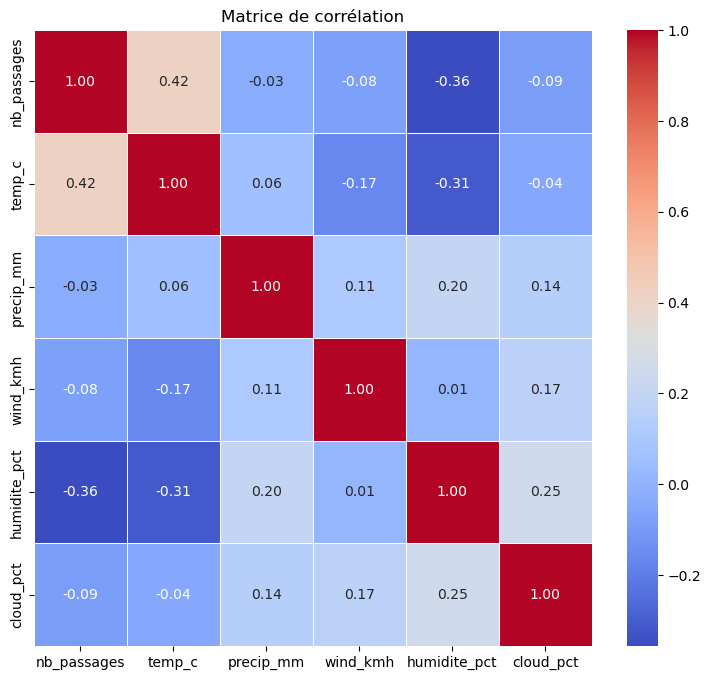

In [944]:
import matplotlib.pyplot as plt
  
df_1 = df.select_dtypes(include=[np.number])
correlation_matrix = df_1.corr()

plt.figure(figsize=(9, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

In [945]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000



# ***1 - transformation date en :*** 
#     - ***Jour Semaine***
#     - ***Mois***
--------------------------------------------------------------------------------------

# ***2 - transformation Heure  en :***
#     - ***Minutes*** : [00:00 = 0 , 00:15 = 15 , 07:45 = 465 , 17:00=1020 ]

In [947]:
##### from datetime import datetime

#df_final_v1 = datetime.strptime(df_final_v0['date'] , "%Y-%m-%d")
df['date']         = pd.to_datetime(df['date'])
df["jour_semaine"] = df["date"].dt.dayofweek
df["mois"]         = df["date"].dt.month
df['heure']        = pd.to_timedelta(df['heure'])
df['minutes']      = df['heure'].dt.total_seconds()/60 #).astype(int)
df['hh_mm']        = df['minutes'].apply(lambda x: f"{x // 60:02.0f}:{x % 60:02.0f}")

df.sample(5)

,date,heure,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,hh_mm
644650,2025-06-25,0 days 17:15:00,41.0,29.4,0.0,16.1,19.0,1.0,2,6,1035.0,17:15
657497,2025-06-29,0 days 08:00:00,10.0,19.1,0.0,12.6,79.0,36.0,6,6,480.0,08:00
5043,2025-01-02,0 days 06:45:00,0.0,-1.7,0.0,24.1,80.0,100.0,3,1,405.0,06:45
510341,2025-05-18,0 days 18:45:00,2.0,10.9,1.0,20.8,85.0,100.0,6,5,1125.0,18:45
360377,2025-04-07,0 days 10:45:00,1.0,3.8,0.0,6.3,41.0,0.0,0,4,645.0,10:45


- **Le bute de la création des colonnes hh_mm pour s'assurer que minutes focntionne bien**
- **minute va remplacer heure dans la journée**
- **mois et jours_semaine vont remplacer la date**

**On ajoute une colonne heure qui pourra etre pertinante pour le choix des decripteurs**

In [950]:
from datetime import datetime
df['h'] = df['heure'].dt.components['hours']
df.head(5)

,date,heure,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,hh_mm,h
0,2025-01-01,0 days,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,00:00,0
1,2025-01-01,0 days,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,00:00,0
2,2025-01-01,0 days,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,00:00,0
3,2025-01-01,0 days,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,00:00,0
4,2025-01-01,0 days,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,00:00,0


### ***Drope colonnes ['hh_mm','date','heure']***

In [952]:
df = df.drop(columns=['hh_mm','date','heure'])
df.head(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h
0,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0
1,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0
2,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0
3,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0


###### --------------------------------------------------------------------------------------

# **Création des periode de temps pour controler les moments d'achalendage**
# - ***00:00 - 07:00 ----------> minutes entre ( 0000  - 420  ) ----------> : 1***
# - ***07:00 - 09:30 ----------> minutes entre ( 0420  - 570  ) ----------> : 2***
# - ***09:30 - 11:30 ----------> minutes entre ( 0570  - 690  ) ----------> : 3***
# - ***11:30 - 13:30 ----------> minutes entre ( 0690  - 810  ) ----------> : 4***
# - ***13:30 - 16:30 ----------> minutes entre ( 0810  - 990  ) ----------> : 5***
# - ***16:30 - 18:00 ----------> minutes entre ( 0990  - 1080 ) ----------> : 6***
# - ***18:00 - 21:00 ----------> minutes entre ( 1080  - 1260 ) ----------> : 7***
# - ***21:00 - 23:59 ----------> minutes entre ( 1260  - 1439 ) ----------> : 8***
 
--------------------------------------------------------------------------------------    


In [954]:
# Les bornes des intervalles
# Creation 4 periodes de temps

conditions = [
    (df['minutes'] >= 0  )   & (df['minutes'] < 690  ),
    (df['minutes'] >= 690 )  & (df['minutes'] < 990  ),
    (df['minutes'] >= 990 )  & (df['minutes'] < 1260 ),
    (df['minutes'] >= 1260 )
]

# Les codes associés (même longueur que nb d'intervalles)
Codes  = [1,2,3,4]

df['periode_code_4'] = np.select(conditions, Codes, default=0)  # 0 si < 10

df.sample(10)


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4
68318,8.0,0.6,1.0,11.3,94.0,100.0,5,1,1080.0,18,3
217271,0.0,-7.1,0.0,6.0,81.0,54.0,3,2,180.0,3,1
19842,0.0,-16.0,0.0,6.3,71.0,1.0,0,1,180.0,3,1
577282,13.0,24.8,0.0,7.0,41.0,4.0,4,6,1080.0,18,3
491112,44.0,20.9,0.0,10.0,40.0,13.0,1,5,705.0,11,2
473299,0.0,9.2,0.0,9.8,68.0,100.0,3,5,885.0,14,2
69527,0.0,-1.6,0.0,13.5,86.0,100.0,6,1,90.0,1,1
146275,0.0,-9.6,0.0,12.3,73.0,8.0,5,2,75.0,1,1
311666,0.0,0.7,0.0,13.2,93.0,100.0,1,3,135.0,2,1
251168,0.0,-8.1,0.0,23.7,64.0,92.0,5,3,675.0,11,1


In [955]:
# Les bornes des intervalles
#ornes = [0,420,570,690,810,990,1080,1260]

# Création de 8 periodes de temps

conditions = [
    (df['minutes'] >= 0  )   & (df['minutes'] < 420  ),
    (df['minutes'] >= 420 )  & (df['minutes'] < 570  ),
    (df['minutes'] >= 570 )  & (df['minutes'] < 690  ),
    (df['minutes'] >= 690 )  & (df['minutes'] < 810  ),
    (df['minutes'] >= 810 )  & (df['minutes'] < 990  ),
    (df['minutes'] >= 990 )  & (df['minutes'] < 1080 ),
    (df['minutes'] >= 1080 ) & (df['minutes'] < 1260 ),
    (df['minutes'] >= 1260 )
]

# Les codes associés (même longueur que nb d'intervalles)
Codes  = [1,2,3,4,5,6,7,8]

df['periode_code_8'] = np.select(conditions, Codes, default=0)  # 0 si < 10

df.sample(10)


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
111189,0.0,-10.4,0.0,16.0,68.0,100.0,2,1,1320.0,22,4,8
166224,0.0,-6.5,2.0,17.9,89.0,100.0,3,2,480.0,8,1,2
342402,0.0,-1.0,0.0,7.9,36.0,100.0,2,4,750.0,12,2,4
346975,29.0,14.8,0.0,18.8,72.0,56.0,3,4,1110.0,18,3,7
246072,0.0,-7.0,0.0,22.5,83.0,100.0,4,3,105.0,1,1,1
649913,0.0,15.9,0.0,3.4,64.0,100.0,4,6,285.0,4,1,1
348050,1.0,4.9,0.0,14.5,67.0,59.0,4,4,90.0,1,1,1
537818,5.0,18.9,0.0,7.1,62.0,10.0,0,5,750.0,12,2,4
533361,4.0,7.6,0.0,8.0,90.0,30.0,6,5,390.0,6,1,1
440682,0.0,19.7,0.0,9.5,70.0,100.0,1,4,915.0,15,2,5


In [956]:
# Exporter vers un csv
#-------------------------------------
df.to_csv('Trafic_velo.csv', index=False)

# ***Graphiques***

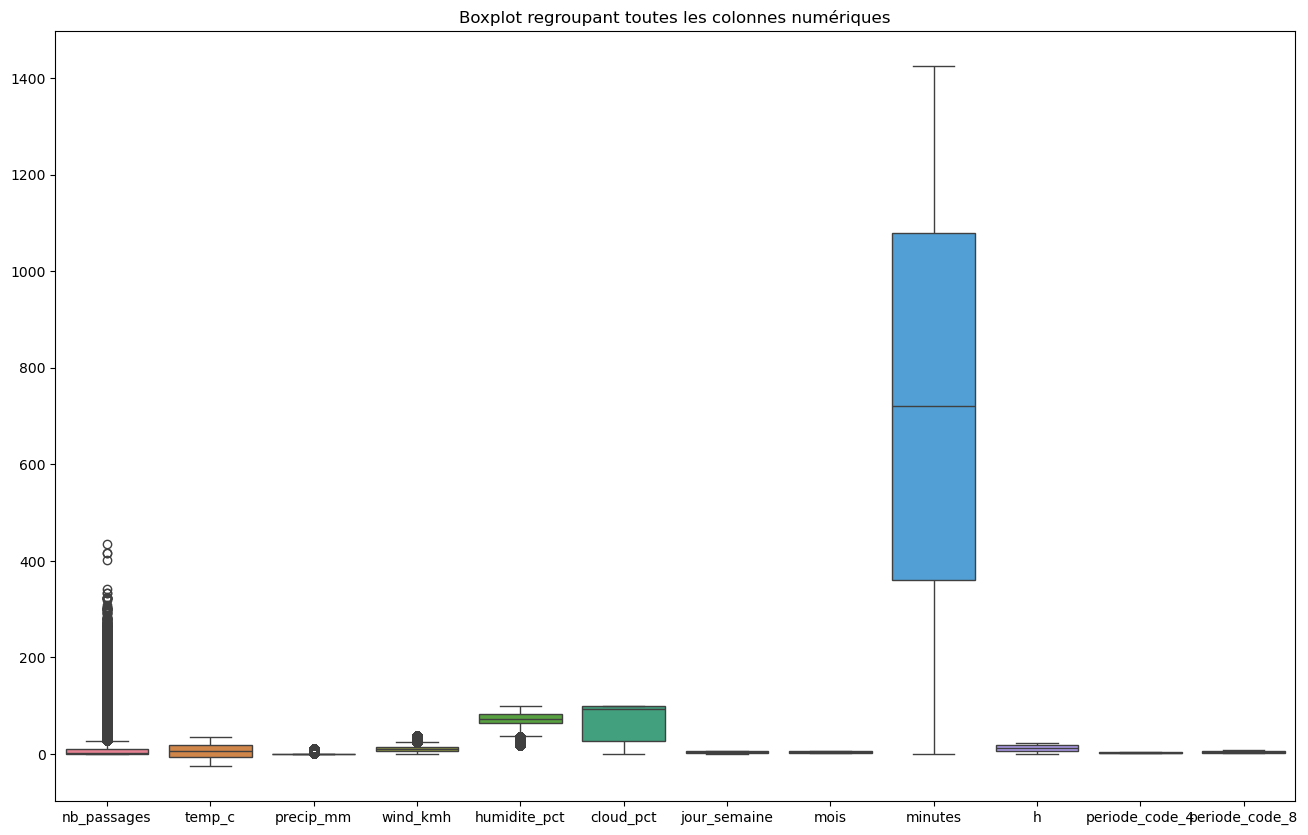

In [958]:
# affiche tous les colonnes
#import seaborn as sns

plt.figure(figsize=(16,10))
sns.boxplot(data=df)
plt.title("Boxplot regroupant toutes les colonnes numériques")
plt.show()